# LLM Embeddings → K-Means Clustering of Session Inputs

Load a small (T4/8GB-friendly) embedding model, serialize each sample
(`session_meta + history + current_prompt`) to text, embed it, run K-Means, and plot
the cluster distribution vs the true `action` label.

**Goal:** see whether an LLM's representation of the *input context* separates the 14
actions in an unsupervised way — a sanity check on how much signal the raw text carries
before we commit to fine-tuning.

**Hardware:** local RTX 4060 = **8 GB VRAM** (dev), submission server = T4 **16 GB**.
Task is **text-only** (no images) → use a code/multilingual text encoder, not a VLM.

**Constraint that drove the model choice:** the submission pins `transformers==4.46.3`,
which does **not** support `qwen3` (Qwen3-Embedding fails with `KeyError: 'qwen3'`).
So we use `intfloat/multilingual-e5-small` (BERT backbone, loads natively on 4.46.3).

In [1]:
import json, csv
from pathlib import Path
import numpy as np

DATA = Path("..") / "data"
labels = {}
with open(DATA / "train_labels.csv", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        labels[row["id"]] = row["action"]

rows = []
with open(DATA / "train.jsonl", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))
y = np.array([labels[r["id"]] for r in rows])
CLASSES = sorted(set(y))
print(f"rows={len(rows)}  classes={len(CLASSES)}")


def serialize(r, max_hist=6):
    """Flatten a sample into one text string for the encoder."""
    sm = r["session_meta"]; ws = sm["workspace"]
    parts = [
        f"[tier={sm['user_tier']} lang={sm['language_pref']} turn={sm['turn_index']} "
        f"budget={sm['budget_tokens_remaining']} ci={ws['last_ci_status']} "
        f"dirty={ws['git_dirty']} open={','.join(ws['open_files']) or '-'}]"
    ]
    for t in r["history"][-max_hist:]:
        if t.get("role") == "user":
            parts.append(f"USER: {t['content']}")
        else:
            parts.append(f"ACTION {t['name']}({t.get('args',{})}) -> {t.get('result_summary','')}")
    parts.append(f"PROMPT: {r['current_prompt']}")
    return "\n".join(parts)


texts = [serialize(r) for r in rows]
print("\n--- example serialized input ---\n")
print(texts[1][:800])

rows=70000  classes=14

--- example serialized input ---

[tier=pro lang=en turn=1 budget=126987 ci=none dirty=True open=-]
PROMPT: i added a couple cases to the spec earlier — open it so i can double check, cheers


## Load embedding model — `Qwen/Qwen3-Embedding-0.6B`

**Update:** we bumped the submission's `requirements.txt` from `transformers==4.46.3`
→ **`4.51.3`** (first version with the `qwen3` architecture), so Qwen3-Embedding is now
usable end-to-end. The bump only changes `transformers`+`tokenizers` — no conflict with
the pinned `torch==2.7.1`.

Chosen because: Apache-2.0, ~1.2 GB VRAM fp16 (fits the 8 GB 4060), multilingual (EN+KO),
trained for **code** retrieval/clustering, 1024-dim, 32K context — the strongest small
encoder available. Convention: **last-token pooling**, left padding, no query prefix.

> Fallback if the eval server ever rejects 4.51.3: revert to 4.46.3 +
> `intfloat/multilingual-e5-small` (BERT backbone, mean-pool, `"query: "` prefix).

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_ID = "Qwen/Qwen3-Embedding-0.6B"   # needs transformers>=4.51 (we bumped requirements to 4.51.3)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}  model={MODEL_ID}")

tok = AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")   # left-pad for last-token pool
model = AutoModel.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device).eval()
print(f"loaded. params={sum(p.numel() for p in model.parameters())/1e9:.2f}B  dim={model.config.hidden_size}")
if device == "cuda":
    print(f"VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")


def last_token_pool(last_hidden, attn_mask):
    # Qwen3-Embedding: pool the last non-pad token. With left padding -> index -1.
    left_padded = (attn_mask[:, -1].sum() == attn_mask.shape[0])
    if left_padded:
        return last_hidden[:, -1]
    lengths = attn_mask.sum(1) - 1
    return last_hidden[torch.arange(last_hidden.shape[0]), lengths]


@torch.no_grad()
def embed(text_list, batch_size=64, max_len=512, prefix=""):
    # Qwen3-Embedding: no "query:" prefix needed for clustering (raw text is fine).
    out = []
    for i in range(0, len(text_list), batch_size):
        batch = [prefix + t for t in text_list[i:i + batch_size]]
        enc = tok(batch, padding=True, truncation=True, max_length=max_len,
                  return_tensors="pt").to(device)
        h = model(**enc).last_hidden_state
        emb = last_token_pool(h, enc["attention_mask"])
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
        out.append(emb.float().cpu().numpy())
        if i % (batch_size * 10) == 0:
            print(f"  embedded {i+len(batch)}/{len(text_list)}", end="\r")
    return np.vstack(out)

device=cuda  model=Qwen/Qwen3-Embedding-0.6B


loaded. params=0.60B  dim=1024
VRAM allocated: 1.19 GB


In [3]:
# embed a subsample (bump N_SUB for full run; 8000 keeps it fast on 8GB)
N_SUB = 8000
rng = np.random.default_rng(42)
sub = rng.choice(len(texts), size=min(N_SUB, len(texts)), replace=False)
sub_texts = [texts[i] for i in sub]
sub_y = y[sub]

import time
t0 = time.time()
emb = embed(sub_texts, batch_size=64, max_len=512)
print(f"\nembeddings: {emb.shape}  in {time.time()-t0:.1f}s")

# free the model from GPU — downstream (kmeans, PCA/t-SNE/UMAP) is CPU-only on `emb`.
del model
if device == "cuda":
    torch.cuda.empty_cache()
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")


embeddings: (8000, 1024)  in 175.8s
VRAM after cleanup: 0.01 GB


## K-Means clustering

Cluster the embeddings and check alignment with the true `action` (and the 4 semantic
families from `data_stats.ipynb` §7). If clusters map cleanly to actions/families, the
LLM representation already separates them unsupervised.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

FAMILY = {
    "read_file":"Read","grep_search":"Read","list_directory":"Read","glob_pattern":"Read",
    "edit_file":"Write","write_file":"Write","apply_patch":"Write",
    "run_bash":"Exec","run_tests":"Exec","lint_or_typecheck":"Exec",
    "ask_user":"Meta","plan_task":"Meta","web_search":"Meta","respond_only":"Meta",
}
fam_y = np.array([FAMILY[a] for a in sub_y])

for k in [4, 14]:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(emb)
    cl = km.labels_
    print(f"--- k={k} ---")
    print(f"  vs ACTION(14): ARI={adjusted_rand_score(sub_y, cl):.3f}  NMI={normalized_mutual_info_score(sub_y, cl):.3f}")
    print(f"  vs FAMILY(4) : ARI={adjusted_rand_score(fam_y, cl):.3f}  NMI={normalized_mutual_info_score(fam_y, cl):.3f}")
    print(f"  silhouette   : {silhouette_score(emb, cl):.3f}")
    if k == 14:
        km14, cl14 = km, cl

--- k=4 ---
  vs ACTION(14): ARI=0.007  NMI=0.020
  vs FAMILY(4) : ARI=0.015  NMI=0.013


  silhouette   : 0.035


--- k=14 ---
  vs ACTION(14): ARI=0.010  NMI=0.032
  vs FAMILY(4) : ARI=0.008  NMI=0.014


  silhouette   : 0.037


## Plot the distribution

1. **Cluster × action heatmap** — how each k-means cluster (k=14) splits across true actions.
2. **2D projection** (PCA) coloured by true action and by cluster.

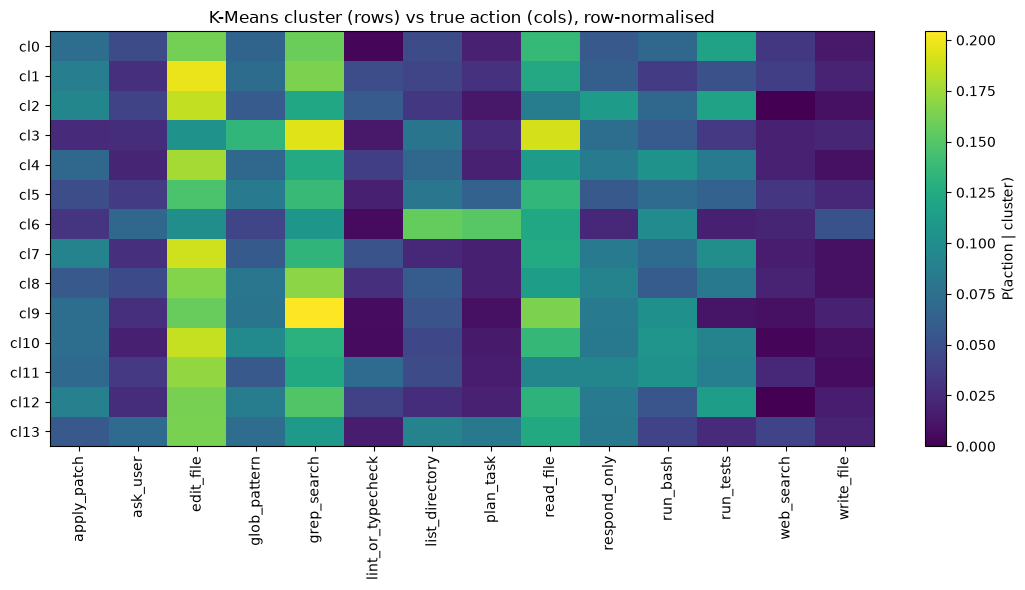

cluster -> dominant action (purity):
  cl 0  n= 366  edit_file        p=0.16  fam=Write
  cl 1  n= 868  edit_file        p=0.20  fam=Write
  cl 2  n= 544  edit_file        p=0.19  fam=Write
  cl 3  n= 865  grep_search      p=0.19  fam=Read
  cl 4  n= 424  edit_file        p=0.18  fam=Write
  cl 5  n= 436  edit_file        p=0.15  fam=Write
  cl 6  n= 794  list_directory   p=0.16  fam=Read
  cl 7  n= 998  edit_file        p=0.19  fam=Write
  cl 8  n= 438  grep_search      p=0.17  fam=Read
  cl 9  n= 421  grep_search      p=0.20  fam=Read
  cl10  n= 338  edit_file        p=0.19  fam=Write
  cl11  n= 702  edit_file        p=0.17  fam=Write
  cl12  n= 370  edit_file        p=0.16  fam=Write
  cl13  n= 436  edit_file        p=0.16  fam=Write


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# cluster x action contingency (row-normalised)
ct = pd.crosstab(cl14, sub_y)
ct = ct[CLASSES]                       # fixed column order
ctn = ct.div(ct.sum(1), axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(ctn.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=90)
ax.set_yticks(range(ctn.shape[0])); ax.set_yticklabels([f"cl{c}" for c in ctn.index])
ax.set_title("K-Means cluster (rows) vs true action (cols), row-normalised")
fig.colorbar(im, ax=ax, label="P(action | cluster)")
plt.tight_layout(); plt.show()

# each cluster's dominant action + purity
print("cluster -> dominant action (purity):")
for c in ctn.index:
    top = ctn.loc[c].idxmax()
    print(f"  cl{c:2d}  n={int(ct.loc[c].sum()):4d}  {top:16s} p={ctn.loc[c].max():.2f}  fam={FAMILY[top]}")

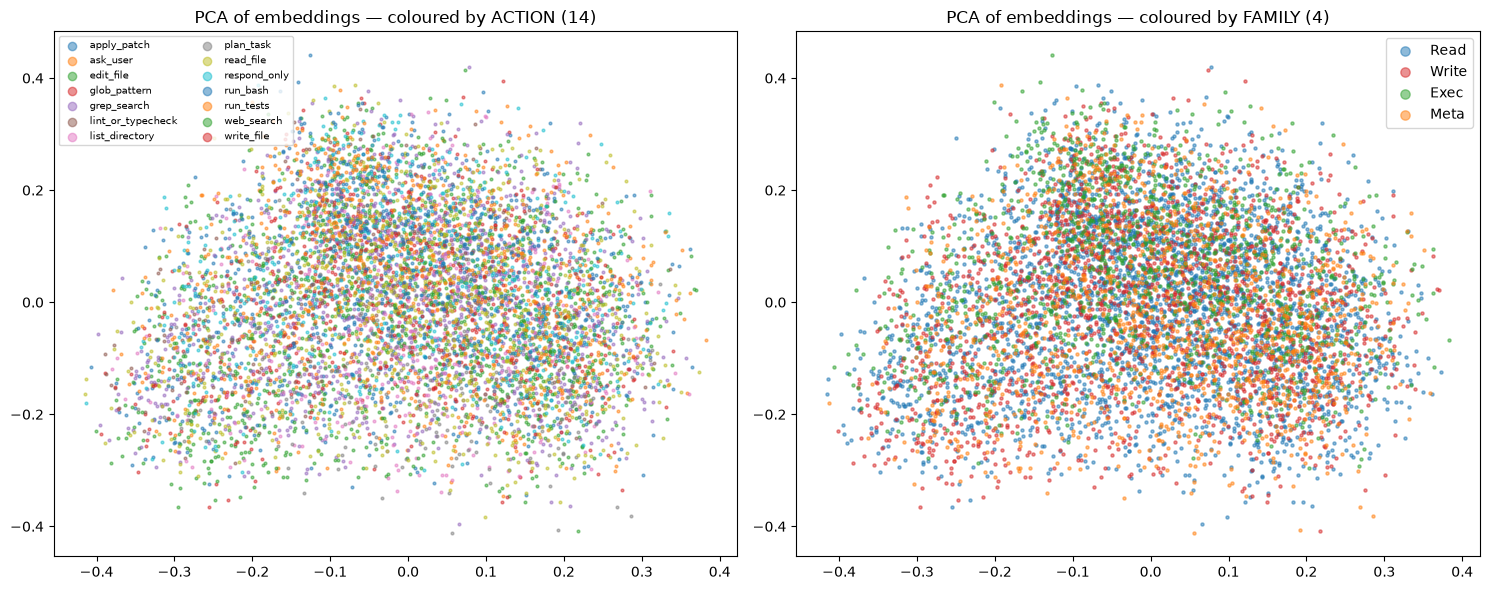

In [6]:
# 2D PCA projection, coloured by true action (left) and by family (right)
from sklearn.decomposition import PCA
xy = PCA(n_components=2, random_state=0).fit_transform(emb)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# by action
for a in CLASSES:
    m = sub_y == a
    axes[0].scatter(xy[m, 0], xy[m, 1], s=4, alpha=0.5, label=a)
axes[0].set_title("PCA of embeddings — coloured by ACTION (14)")
axes[0].legend(markerscale=3, fontsize=7, ncol=2, loc="best")
# by family
fam_colors = {"Read":"tab:blue","Write":"tab:red","Exec":"tab:green","Meta":"tab:orange"}
for fam, col in fam_colors.items():
    m = fam_y == fam
    axes[1].scatter(xy[m, 0], xy[m, 1], s=5, alpha=0.5, c=col, label=fam)
axes[1].set_title("PCA of embeddings — coloured by FAMILY (4)")
axes[1].legend(markerscale=3)
plt.tight_layout(); plt.show()

### Nonlinear projections — t-SNE & UMAP

PCA is linear, so a lack of separation there isn't conclusive (classes could be
nonlinearly separable). t-SNE (local neighborhoods) and UMAP (local + some global)
are the honest visual check. If the labels are *still* mixed under these, it corroborates
the ARI≈0 / silhouette≈0.03 quantitative result — the embeddings really don't encode the
next-action decision.

> Both are unsupervised (they never see `y`); coloring is applied only after projection.
> `umap-learn` is a local dev dependency — NOT added to the submission `requirements.txt`.

t-SNE on 3000 pts in 4.3s


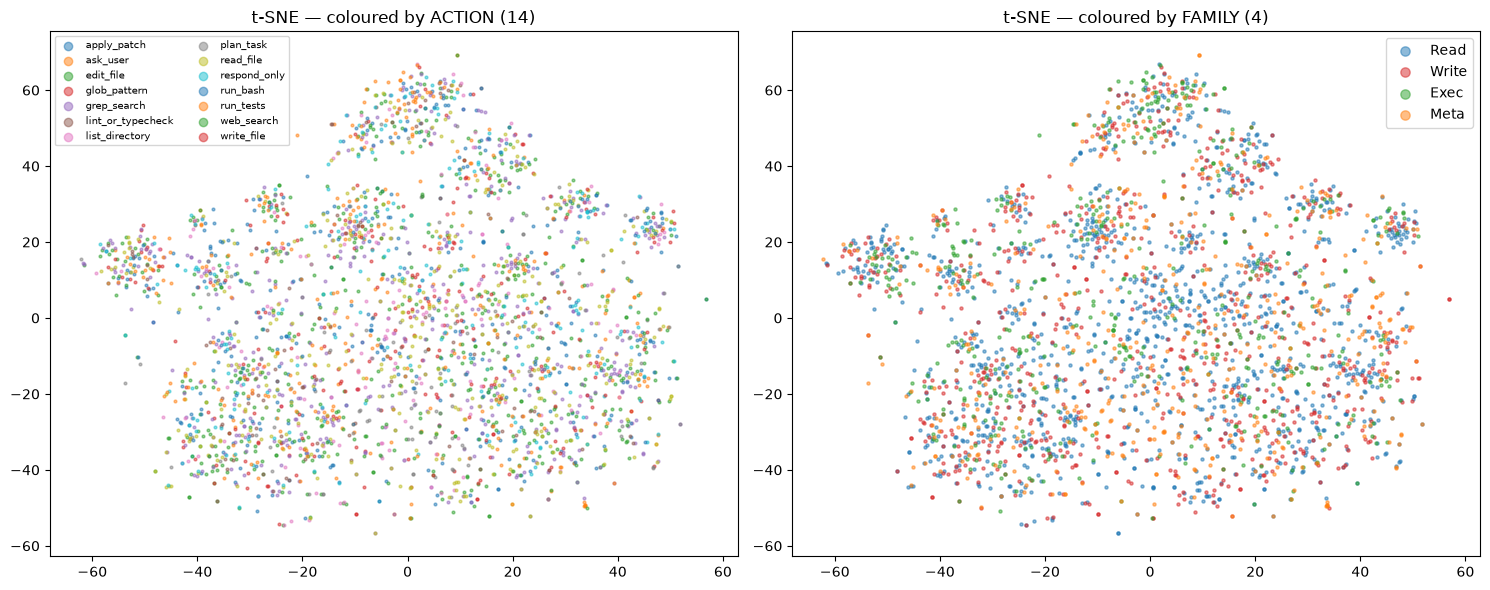

In [7]:
def plot_projection(xy2d, title):
    """Scatter a 2D projection, colored by ACTION (left) and by FAMILY (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for a in CLASSES:
        m = sub_y == a
        axes[0].scatter(xy2d[m, 0], xy2d[m, 1], s=4, alpha=0.5, label=a)
    axes[0].set_title(f"{title} — coloured by ACTION (14)")
    axes[0].legend(markerscale=3, fontsize=7, ncol=2, loc="best")
    fam_colors = {"Read":"tab:blue","Write":"tab:red","Exec":"tab:green","Meta":"tab:orange"}
    for fam, col in fam_colors.items():
        m = fam_y == fam
        axes[1].scatter(xy2d[m, 0], xy2d[m, 1], s=5, alpha=0.5, c=col, label=fam)
    axes[1].set_title(f"{title} — coloured by FAMILY (4)")
    axes[1].legend(markerscale=3)
    plt.tight_layout(); plt.show()


# t-SNE (O(n^2)-ish; subsample for speed). Uses the full 1024-dim embeddings as input.
from sklearn.manifold import TSNE
n_tsne = min(3000, len(emb))
sel = np.random.default_rng(0).choice(len(emb), n_tsne, replace=False)
t0 = time.time()
xy_tsne = TSNE(n_components=2, perplexity=30, init="pca",
               random_state=0).fit_transform(emb[sel])
print(f"t-SNE on {n_tsne} pts in {time.time()-t0:.1f}s")

# reuse plot helper on the t-SNE subset
_sub_y, _fam_y = sub_y, fam_y
sub_y, fam_y = sub_y[sel], fam_y[sel]
plot_projection(xy_tsne, "t-SNE")
sub_y, fam_y = _sub_y, _fam_y   # restore full arrays

/home/kyusang/research/dacon/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP on 8000 pts in 24.4s


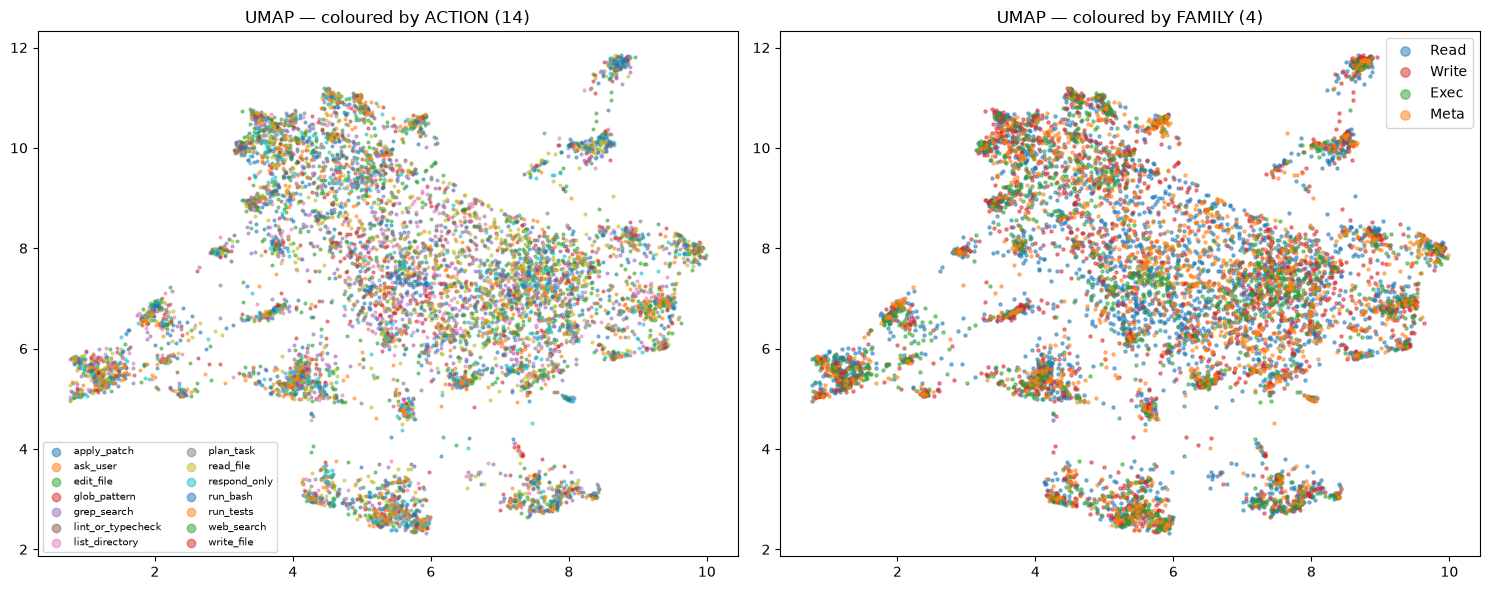

In [8]:
# UMAP (scales to all 8k; local + some global structure). Cosine metric suits normalized embeddings.
import umap
t0 = time.time()
xy_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric="cosine", random_state=0).fit_transform(emb)
print(f"UMAP on {len(emb)} pts in {time.time()-t0:.1f}s")
plot_projection(xy_umap, "UMAP")

## Result — unsupervised clustering does NOT recover the actions

**K-means shows no alignment with the label — and this holds across two encoders AND
across three projection methods.**

| Encoder | dim | k=14 vs ACTION ARI/NMI | k=4 vs FAMILY ARI/NMI | silhouette |
|---|---|---|---|---|
| `multilingual-e5-small` | 384 | 0.020 / 0.066 | −0.009 / 0.011 | 0.02–0.10 |
| `Qwen3-Embedding-0.6B` | 1024 | **0.010 / 0.032** | 0.015 / 0.013 | 0.035 |

ARI ≈ 0 = **no better than random** w.r.t. the action, for *both* models. Max cluster
purity **0.20** (vs 0.16 base rate); most clusters default to `edit_file` (the majority
class). Silhouette ≈ 0.03 ⇒ no natural cluster structure.

**PCA / t-SNE / UMAP all agree.** The nonlinear projections (t-SNE, UMAP) *do* show
blobs/sub-clusters — but every action (14) and family (4) color is thoroughly **mixed
inside each blob**; no region is action- or family-dominated. So the structure the
embedding captures is **topic** (which file/language/session-type), not the **next-action
decision**. This rules out the "PCA is linear so maybe it's hiding separation" objection —
even nonlinear methods find no label structure.

### Why (consistent with `data_stats.ipynb`)
- The embedding captures **topic/surface** similarity of the session text, **not** the
  latent decision. Two sessions about the same file can end in `read_file` vs `edit_file` —
  near-identical text, different label; unsupervised distance can't separate them.
- The real signal is **supervised**: prompt+meta LogReg → 0.57, and the clean 4-family
  structure in §7 came from **classifier weight vectors**, not raw embedding geometry.

### Takeaway
**No clustering/retrieval shortcut exists — the label is not separable in unsupervised
embedding space, at any encoder strength or projection method.** The task needs
**supervised fine-tuning**: a classifier head on an encoder (Qwen3-Embedding / bge-m3) or a
Qwen2.5-Coder decoder with a 14-way head. Frozen-embedding similarity is a dead end for
prediction (though embeddings may still help as *one input feature* to a supervised model).